In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)

# Load clean data
df = pd.read_csv("../data/myopia_model_ready.csv")

# Define features and target
X = df.drop('MYOPIC', axis=1)
y = df['MYOPIC']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("DATASET:")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"Myopic in training: {y_train.sum()}")
print(f"Myopic in testing:  {y_test.sum()}")

# Scale data — SVM requires this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nData scaled successfully!")

# Train SVM
model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42,
    C=1.0,
    gamma='scale',
    probability=True
)
model.fit(X_train_scaled, y_train)
print("SVM trained successfully!")

DATASET:
Training set: 494 patients
Testing set:  124 patients
Myopic in training: 65
Myopic in testing:  16

Data scaled successfully!
SVM trained successfully!


SVM RESULTS:
Accuracy:  0.7984
ROC AUC:   0.7726

Classification Report:
              precision    recall  f1-score   support

  Not Myopic       0.90      0.86      0.88       108
      Myopic       0.29      0.38      0.32        16

    accuracy                           0.80       124
   macro avg       0.59      0.62      0.60       124
weighted avg       0.82      0.80      0.81       124



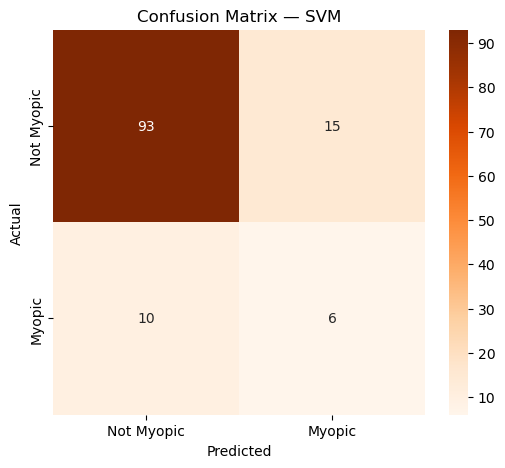

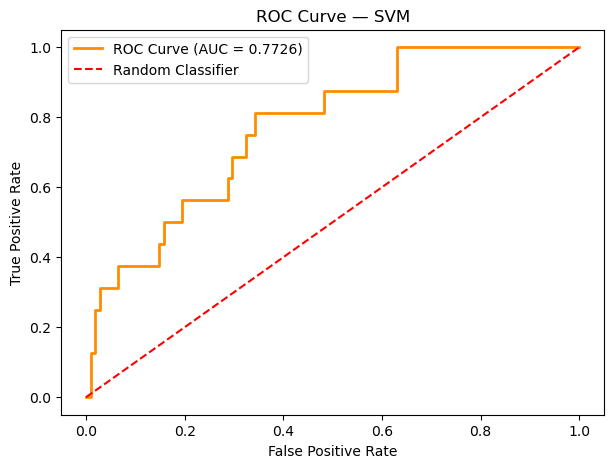


Results saved:
{'Model': 'SVM', 'Accuracy': 0.7984, 'ROC_AUC': 0.7726}

NOTE:
SVM does not provide direct feature importance scores.
It works by finding the optimal boundary between classes
rather than ranking individual feature contributions.


In [2]:
# ============================================
# MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ============================================
# EVALUATION METRICS
# ============================================
print("SVM RESULTS:")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Myopic', 'Myopic']))

# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Myopic', 'Myopic'],
            yticklabels=['Not Myopic', 'Myopic'])
plt.title("Confusion Matrix — SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title("ROC Curve — SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Save results
svm_results = {
    'Model': 'SVM',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_prob), 4)
}
print("\nResults saved:")
print(svm_results)

# ============================================
# NOTE ON FEATURE IMPORTANCE
# ============================================
print("\nNOTE:")
print("SVM does not provide direct feature importance scores.")
print("It works by finding the optimal boundary between classes")
print("rather than ranking individual feature contributions.")